In [19]:
zones = {
    "takeoff": ["W1", "W2", "W3", "W4"],
    "mid":     ["W5", "W6", "W7", "W8"],
    "landing": ["W9", "W10", "W11", "W12"]
}

wind_features = ["Speed", "Tangent", "Cross", "Turbulence"]

In [44]:


def preprocess_flight_normalized(df, step=0.05):
    """
    Preprocess a normalized flight dataframe (already interpolated) to generate states (X), observations (Y), and controls (U).
    
    Args:
        df (pd.DataFrame): Normalized flight dataframe (fixed time step).
        step (float): Time step between rows (used for derivatives).
        
    Returns:
        states (np.ndarray): State matrix [time_steps, state_dim].
        observations (np.ndarray): Observation matrix [time_steps, obs_dim].
        controls (np.ndarray): Control matrix [time_steps, control_dim].
    """

    df.columns = df.columns.str.strip()   #izloči imena stolpcev
    df = df.iloc[1:]
    
    df = df.ffill().bfill()   #back fill za manjkajoče vrednosti
    
    x = df["X [m]"].to_numpy()   #save values
    y = df["Y [m]"].to_numpy()
    z = df["Z [m]"].to_numpy()
    
    dt = step
    #vx = np.gradient(x, dt)   #gradient za hitrost
    vx = df.get("Speed hor. [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)
    vy = np.gradient(y, dt)
    #vz = np.gradient(z, dt)
    vz = df.get("Speed ver. [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)

    speed = df.get("speed resulting [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)

    opening = df.get("Opening Angle [°]", pd.Series([0]*len(x))).to_numpy()
    roll_L = df.get("Roll Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    roll_R = df.get("Roll Angle Right [°]", pd.Series([0]*len(x))).to_numpy()
    yaw_L = df.get("Yaw Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    yaw_R = df.get("Yaw Angle Right [°]", pd.Series([0]*len(x))).to_numpy()
    stall_L = df.get("Stalling Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    stall_R = df.get("Stalling Angle Right [°]", pd.Series([0]*len(x))).to_numpy()

    states = np.stack([x, y, z, vx, vy, vz, speed, opening, roll_L, roll_R, yaw_L, yaw_R, stall_L, stall_R], axis=1)   #zgradimo state vector X

    height = df.get("Height above ground [m]", pd.Series([0]*len(x))).to_numpy()

    observations = np.stack([x, y, z, height], axis=1)   #zgradimo observation vector Y

    #zone_feature_avgs = []
    values = []
    cols = []

    for feature in wind_features:
        for sensor_numb in range(12):
            sensor = f"W{sensor_numb + 1}"
            cols.append(f"{sensor}_{feature}")
            #print(cols)
    for col in cols:
        val = df.get(col, pd.Series([0]*len(x))).to_numpy() 
        values.append(val)
    
    controls = np.stack(values, axis=1)  # shape: (time_steps, 12)

    #for feature in wind_features:
    #    for zone, sensors in zones.items():
    #        cols = [f"{sensor}_{feature}" for sensor in sensors if f"{sensor}_{feature}" in df.columns]
    #        avg_feature = df[cols].mean(axis=1).to_numpy()
    #        zone_feature_avgs.append(avg_feature)
    
    #controls = np.stack(zone_feature_avgs, axis=1)  # shape: (time_steps, 12)
    
    return states, observations, controls


In [45]:
import os
import pandas as pd
import numpy as np

normalized_folder = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\simulation\2024_03_Planica_12_winds\cleaned\normalized'
combined_output = os.path.join(normalized_folder, "combined_dataset.npz")
file_names = []

X_list, Y_list, U_list = [], [], []

for filename in os.listdir(normalized_folder):
    if filename.endswith('.csv'):
        file_path = os.path.join(normalized_folder, filename)
        df = pd.read_csv(file_path)

        X_state, Y_obs, U_ctrl = preprocess_flight_normalized(df)

        X_list.append(X_state)
        Y_list.append(Y_obs)
        U_list.append(U_ctrl)
        file_names.append(filename)

        #if np.any(np.isnan(X_state)):
        #    print(f"NaN values in {filename}")

        print(f"Processed {filename} -> X:{X_state.shape}, Y:{Y_obs.shape}, U:{U_ctrl.shape}")

# Save combined dataset
np.savez(combined_output, X=np.array(X_list, dtype=object), Y=np.array(Y_list, dtype=object), U=np.array(U_list, dtype=object))
print(f"\nCombined dataset saved to {combined_output}")


Processed 999_999_Jumper_Anon_ANO_1_20240409-102625_C_OfficialResults_cleaned_normalized.csv -> X:(135, 14), Y:(135, 4), U:(135, 96)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102742_C_OfficialResults_cleaned_normalized.csv -> X:(131, 14), Y:(131, 4), U:(131, 96)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102831_C_OfficialResults_cleaned_normalized.csv -> X:(145, 14), Y:(145, 4), U:(145, 96)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102832_C_OfficialResults_cleaned_normalized.csv -> X:(139, 14), Y:(139, 4), U:(139, 96)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102833_C_OfficialResults_cleaned_normalized.csv -> X:(136, 14), Y:(136, 4), U:(136, 96)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102834_C_OfficialResults_cleaned_normalized.csv -> X:(132, 14), Y:(132, 4), U:(132, 96)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102835_C_OfficialResults_cleaned_normalized.csv -> X:(156, 14), Y:(156, 4), U:(156, 96)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102836_C_OfficialResults

In [21]:
from sklearn.model_selection import train_test_split
import numpy as np

# Train/test split along time dimension
X_train, X_test, Y_train, Y_test, U_train, U_test = train_test_split(
    X_list, Y_list, U_list, test_size=0.2, random_state=42)


In [22]:
import numpy as np

# Prepare stacked data for system identification
X_t = np.vstack([seq[:-1] for seq in X_train])      # state at time t   
X_next = np.vstack([seq[1:] for seq in X_train])    # state at time t+1  #spustimo 0. da zamaknemo
U_t = np.vstack([u[:-1] for u in U_train])          # control at time t  - matchamo s X_t
Y_t = np.vstack([obs[:-1] for obs in Y_train])      # observation at time t

print(f"X_t: {X_t.shape}, X_next: {X_next.shape}, U_t: {U_t.shape}, Y_t: {Y_t.shape}")


X_t: (22017, 14), X_next: (22017, 14), U_t: (22017, 12), Y_t: (22017, 4)


In [23]:
# Build regression matrix
Phi = np.hstack([X_t, U_t])   # [x_t | u_t]...skupaj sestavimo v eno matriko


Theta, _, _, _ = np.linalg.lstsq(Phi, X_next, rcond=None)  #rešitev po MNK (stabilna verzija)
    #output MNK: matrika A in B, reziduali, rank (A in B), singularnosti (vse razen 1. ignoriramo)
    #ponovimo mnk za vektor, za vsako vrstico v output matriki...MNK za matrike

# Extract A and B
state_dim = X_t.shape[1]
control_dim = U_t.shape[1]
A = Theta[:state_dim, :].T   #prvih state_dim vrstic, vsi stolpci
B = Theta[state_dim:, :].T   #the rest (control_dim)

print("A shape:", A.shape)
print("B shape:", B.shape)


A shape: (14, 14)
B shape: (14, 12)


In [24]:
A

array([[ 1.00827831e+00,  1.68240590e-03,  1.11952662e-02,
         4.01463533e-03,  4.73529265e-03, -7.11236625e-17,
         1.07552856e-16,  2.51708765e-03, -8.03717406e-04,
         9.88200209e-04,  5.37024233e-04, -1.33877271e-03,
         4.69255209e-03,  2.93574208e-03],
       [-3.94391717e-06,  9.99657031e-01, -4.05112345e-06,
        -3.40571414e-07,  5.10994465e-02, -2.77555756e-17,
        -5.82867088e-16,  2.88447218e-05, -5.15524866e-05,
        -5.69969759e-05, -2.69008736e-05,  2.69662138e-05,
         5.52796738e-05, -5.97474625e-05],
       [-1.70273200e-02, -4.40485443e-03,  9.80049801e-01,
        -5.24713870e-04,  3.52718947e-03, -1.24900090e-16,
         1.31838984e-16, -8.40979135e-04, -6.97820986e-04,
         9.17403963e-04,  5.34760787e-04, -5.44143972e-04,
         1.49946956e-03,  2.53296699e-03],
       [-2.37054311e-02,  1.36262863e-02, -3.58529592e-02,
         9.99764902e-01,  2.10229703e-02, -3.46944695e-17,
        -8.32667268e-17,  1.73116884e-02,  8.

In [25]:
Phi_y = np.hstack([X_t, U_t])
Theta_y, _, _, _ = np.linalg.lstsq(Phi_y, Y_t, rcond=None)

obs_dim = Y_t.shape[1]
C = Theta_y[:state_dim, :].T
D = Theta_y[state_dim:, :].T

print("C shape:", C.shape)
print("D shape:", D.shape)


C shape: (4, 14)
D shape: (4, 12)


In [26]:
def simulate_trajectory(x0, U_seq, A, B):
    """
    Simulate trajectory using learned A, B.
    x0: initial state (shape: [state_dim])
    U_seq: control inputs (shape: [T, control_dim])
    """
    X_sim = [x0]  #shrani initial state
    for u in U_seq:                     # @...matrix multiplication
        x_next = A @ X_sim[-1] + B @ u  #Zračuna naslednji korak
        X_sim.append(x_next)            #shrani
    return np.array(X_sim)

# Example: take first flight  (spreminjaš 1. [] pri obeh)
x0 = X_test[0][0]      # first sublist first element
U_seq = U_test[0]      # controls for that flight
X_sim = simulate_trajectory(x0, U_seq, A, B)

print("Simulated trajectory shape:", X_sim.shape)


Simulated trajectory shape: (130, 14)


## funkcije za napako

In [27]:
def point_segment_distance(p, a, b):
    """Distance from point p to segment a-b, and projection point"""
    ap = p-a
    ab = b-a
    denom = np.dot(ab, ab)
    if denom == 0:
        return np.linalg.norm(p-a), a
    t = np.dot(ap, ab) / denom #produkt deljen z normo
    t = np.clip(t, 0, 1)
    proj = a + t* ab
    return np.linalg.norm(p-proj), proj

In [28]:
def curve_projection_distance(curve1, curve2):
    """Mean distance from points in curve1 to curve2's segments"""
    distances = []
    for p in curve1:
        min_dist = float("inf")
        for i in range(len(curve2) - 1):
            dist, _ = point_segment_distance(p, curve2[i], curve2[i + 1])
            if dist < min_dist:
                min_dist = dist
        distances.append(min_dist)
    return np.mean(distances)

In [29]:
def bidirectional_curve_distance(curve_a, curve_b):
    """Symetric bidirectionall mean projection distance"""
    d1 = curve_projection_distance(curve_a, curve_b)
    d2 = curve_projection_distance(curve_b, curve_a)
    return (d1 + d2) / 2

In [30]:
def curve_length (curve):
    return np.sum(np.linalg.norm(np.diff(curve, axis=0), axis=1))

def penalized_bidirectional_distance(curve_a, curve_b, length_weight = 0.5):
    shape_dist = bidirectional_curve_distance(curve_a, curve_b)
    len_a = curve_length(curve_a)
    len_b = curve_length(curve_b)
    length_diff = abs(len_a - len_b)
    return shape_dist + length_weight * length_diff

In [31]:
def downsample_curve(curve, step=10):
    return curve[::step]

In [32]:
#from scipy.spatial import cKDTree
#
#def penalized_bidirectional_distance(A, B, penalty_factor=0.5):
#    tree_A = cKDTree(A)
#    tree_B = cKDTree(B)
#
#    dist_A_to_B, _ = tree_B.query(A)
#    dist_B_to_A, _ = tree_A.query(B)
#
#    mean_A_to_B = np.mean(dist_A_to_B)
#    mean_B_to_A = np.mean(dist_B_to_A)
#
#    return mean_A_to_B + penalty_factor * mean_B_to_A


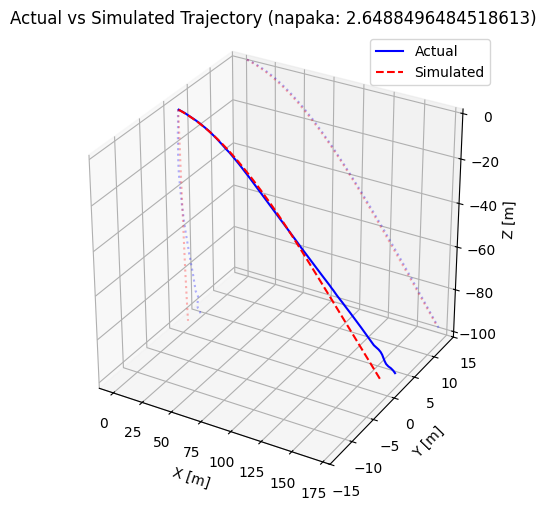

In [33]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

    #(spreminjaš 1. [] v 1. vrstici)
actual = X_test[0][:, :3]   #vzame X,Y,Z iz [x, y, z, vx, vy, vz]
sim = X_sim[:, :3]          # same iz simulacije

Xa = actual[:,0]
Ya = actual[:,1]
Za = actual[:,2]

Xs = sim[:,0]
Ys = sim[:,1]
Zs = sim[:,2]

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

ax.plot3D(Xa, Ya, Za, label="Actual", color="blue")
ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")


# Ground projections
ax.plot(Xa, 15, Za, color="blue", alpha=0.3, linestyle=':')
ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')


ax.plot(0, Ya, Za, color="blue", alpha=0.3, linestyle=':')
ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')


napaka = penalized_bidirectional_distance(actual, sim, 0.5)


ax.set_title(f"Actual vs Simulated Trajectory (napaka: {napaka})")
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_zlabel("Z [m]")
ax.legend()
ax.set_box_aspect([1,1,1])
ax.set_ylim(-15, 15)

plt.legend()
plt.tight_layout()
plt.show()


In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

def plot(X_seq, X_sim, j, name):
    """
    Plot actual vs simulated trajectory in 3D with projections.
    Args:
        X_seq (ndarray): ground truth state sequence (T, state_dim)
        X_sim (ndarray): simulated state sequence (T, state_dim)
        j (int): index of jump
        name (str): identifier for saving plots """

    save_dir = f"plots/{name}"
    os.makedirs(save_dir, exist_ok=True)

    
    actual = X_seq[:, :3]   #vzame X,Y,Z iz [x, y, z, vx, vy, vz]
    sim = X_sim[:, :3]          # same iz simulacije

    Xa, Ya, Za = actual[:,0], actual[:,1], actual[:,2]
    Xs, Ys, Zs = sim[:,0], sim[:,1], sim[:,2]

    napaka = np.mean(np.linalg.norm(actual - sim, axis=1))
    length = (Xs[-1]**2 + Ys[-1]**2 + Zs[-1]**2)**(1/2)
    length_a = (Xa[-1]**2 + Ya[-1]**2 + Za[-1]**2)**(1/2)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot3D(Xa, Ya, Za, label="Actual", color="blue")
    ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")


    # Ground projections
    ax.plot(Xa, 15, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')

    ax.plot(0, Ya, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')


    ax.set_title(f"Actual vs Simulated Trajectory\n Error: {napaka:.3f}, Simulated length: {length:.1f},  Actual length: {length_a:.1f}")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.legend()
    ax.set_box_aspect([1,1,1])
    ax.set_ylim(-15, 15)

    plt.legend()
    #plt.tight_layout()

    filename = f"2SSM flight_simulation{j + 1}.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300)
    plt.close(fig)
    #plt.show()


## plotting

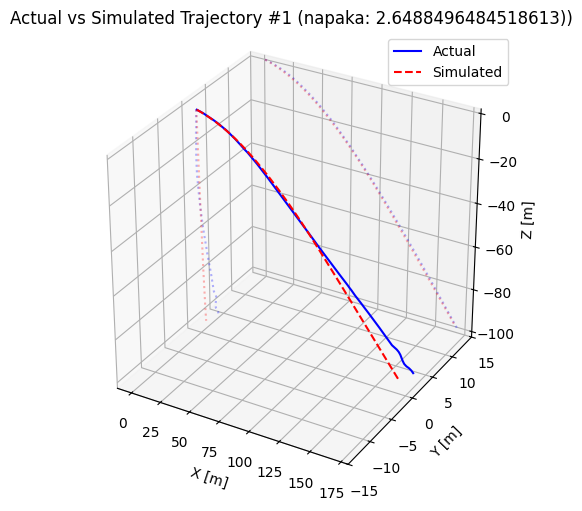

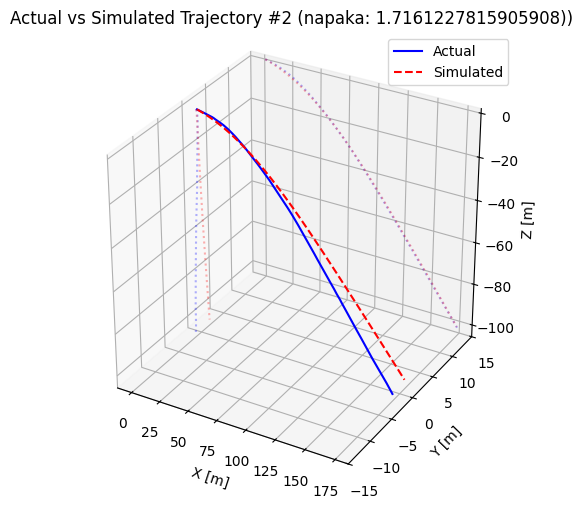

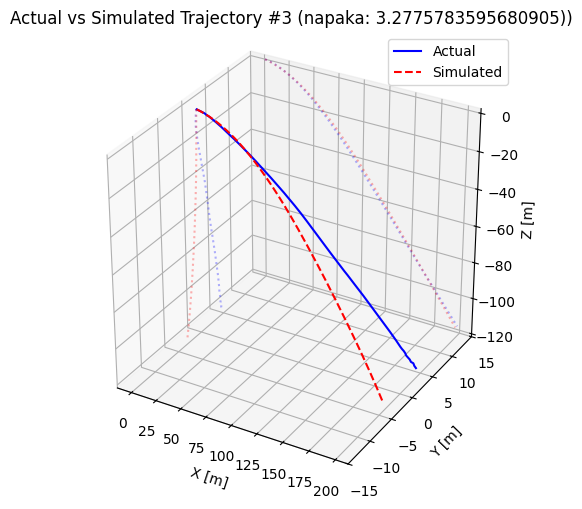

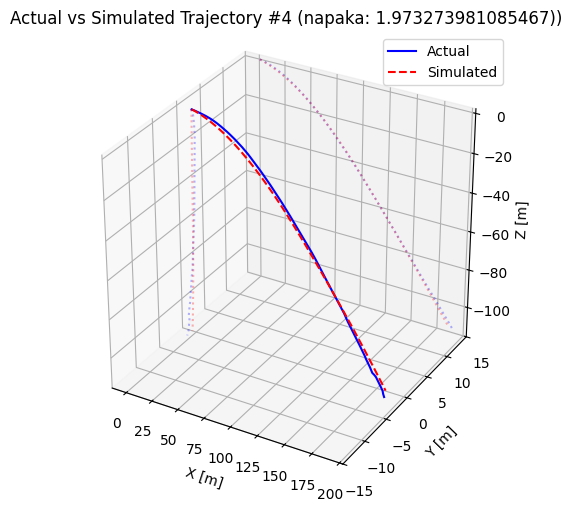

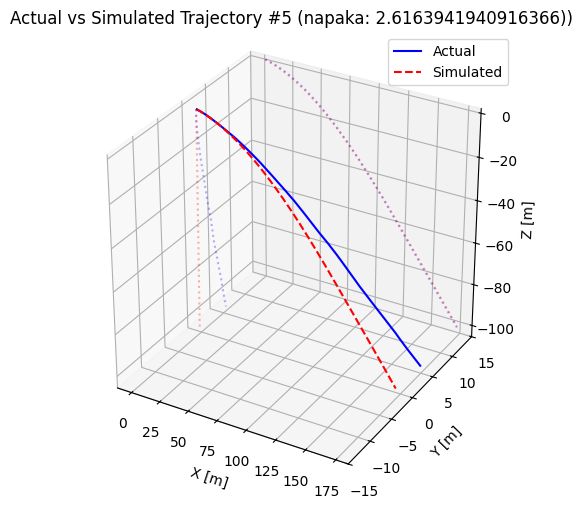

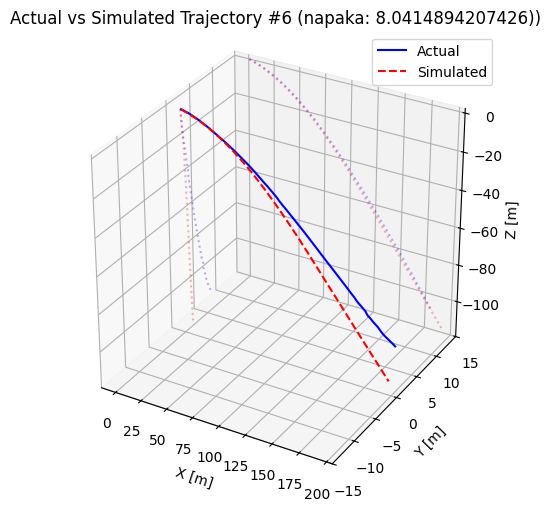

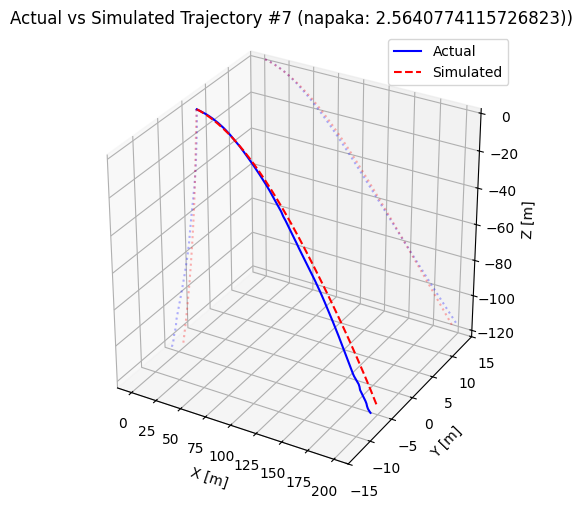

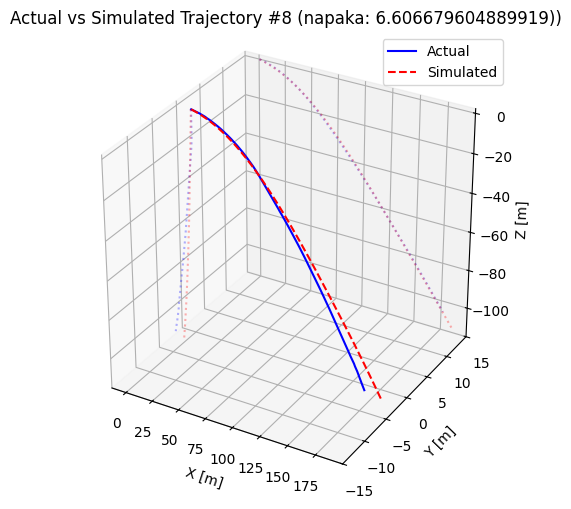

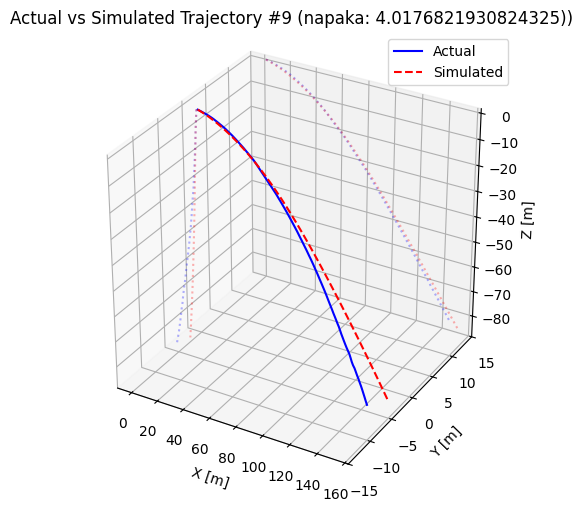

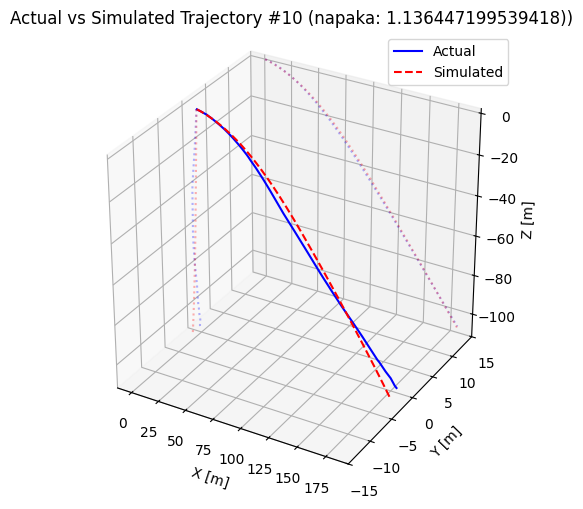

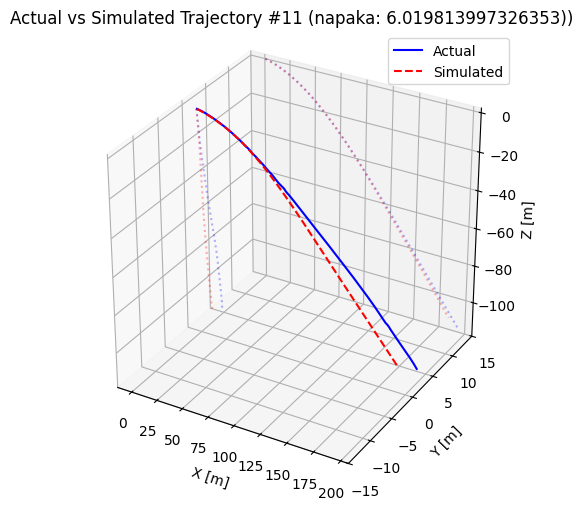

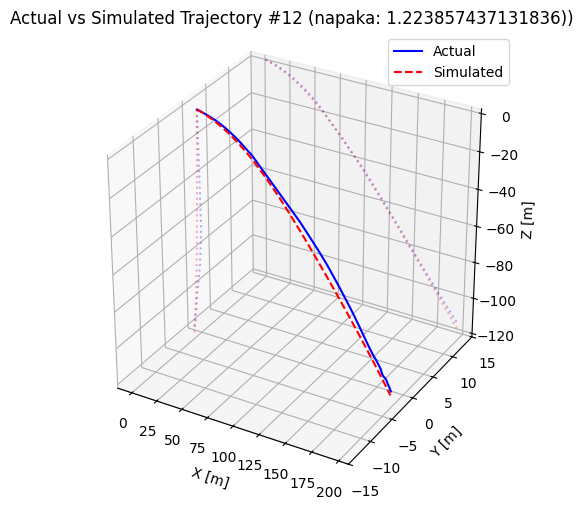

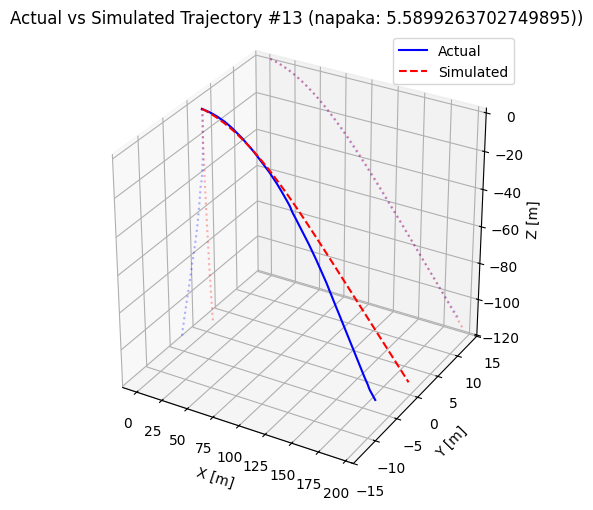

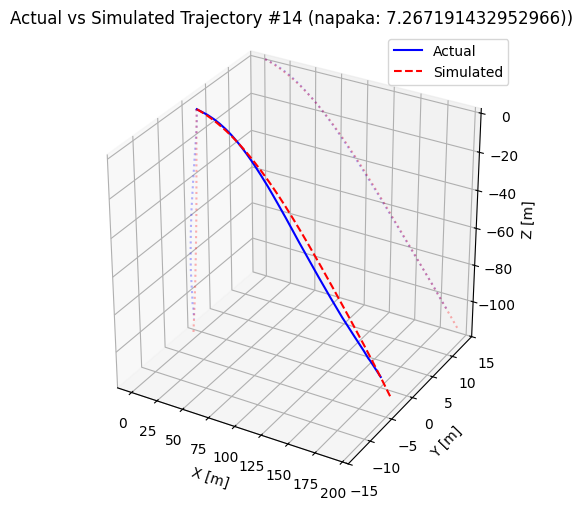

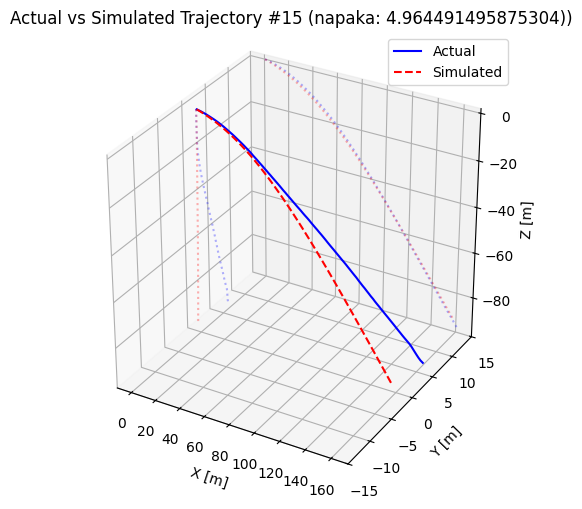

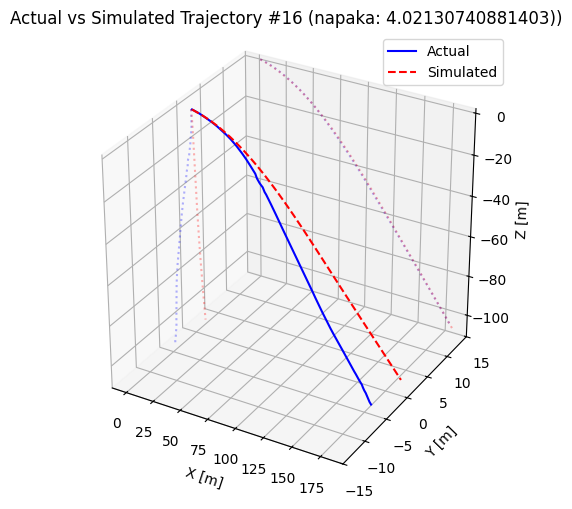

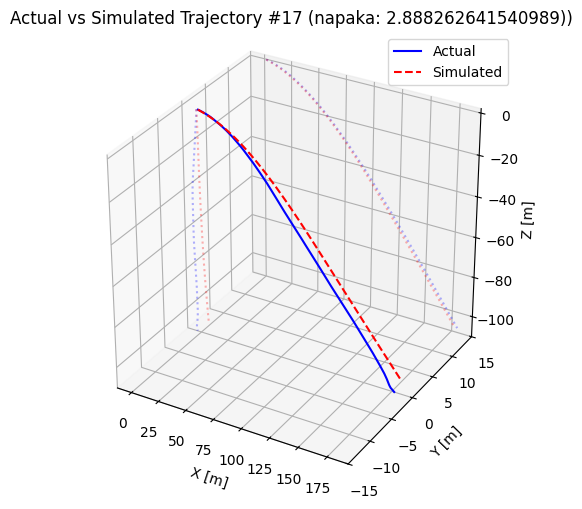

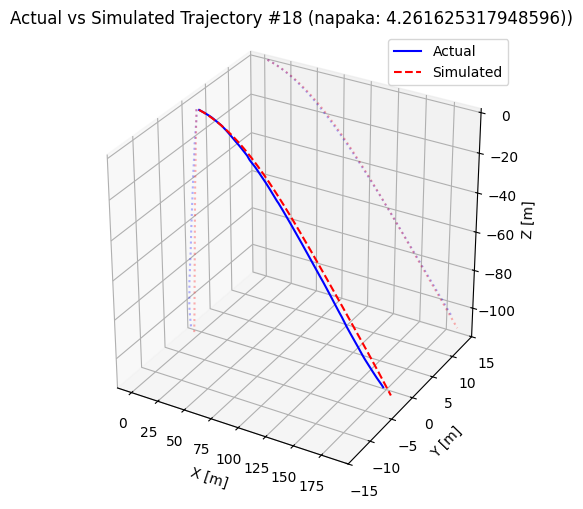

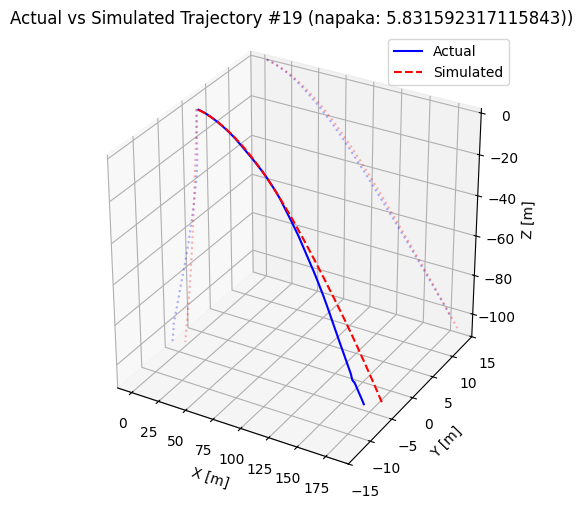

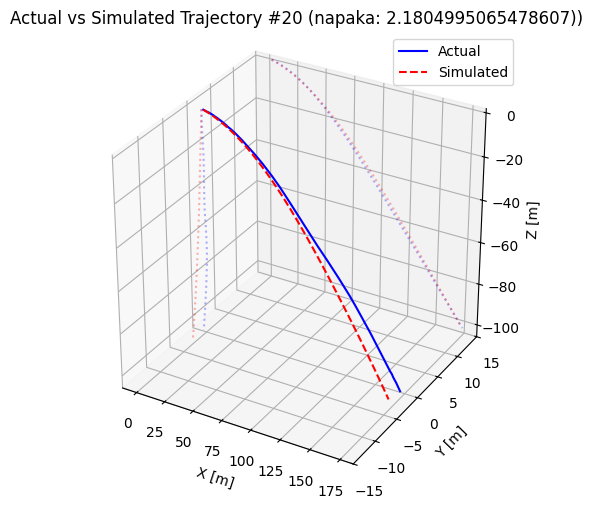

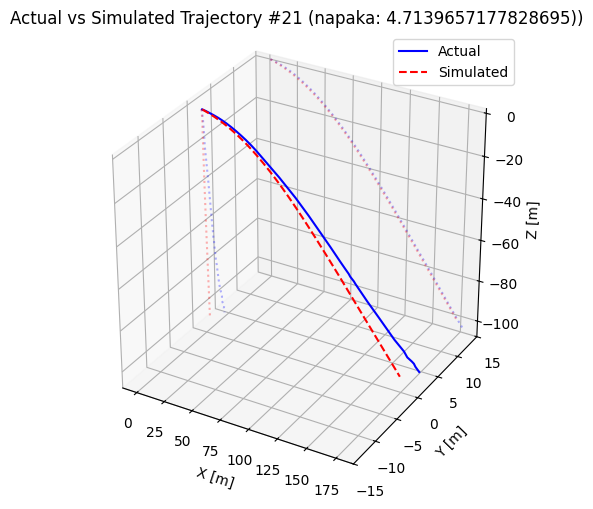

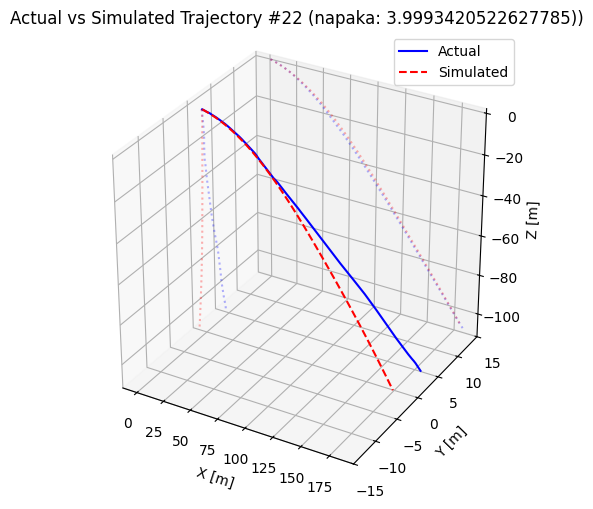

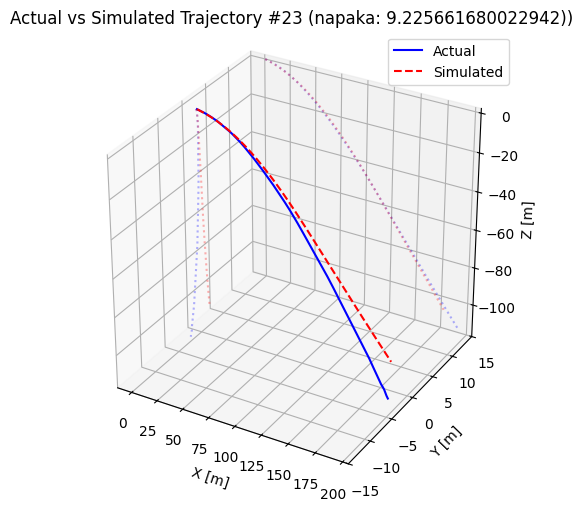

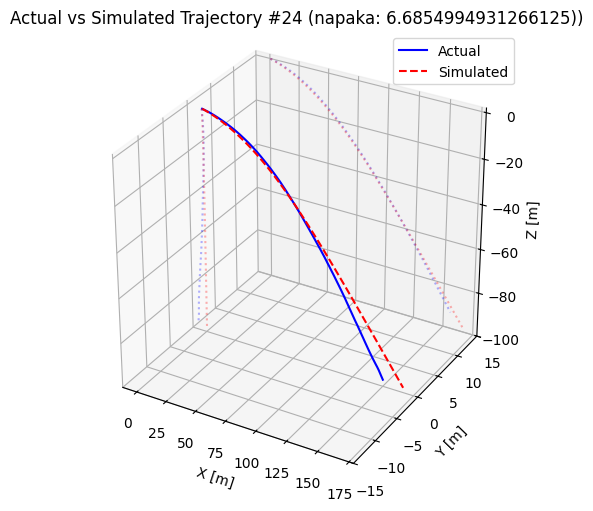

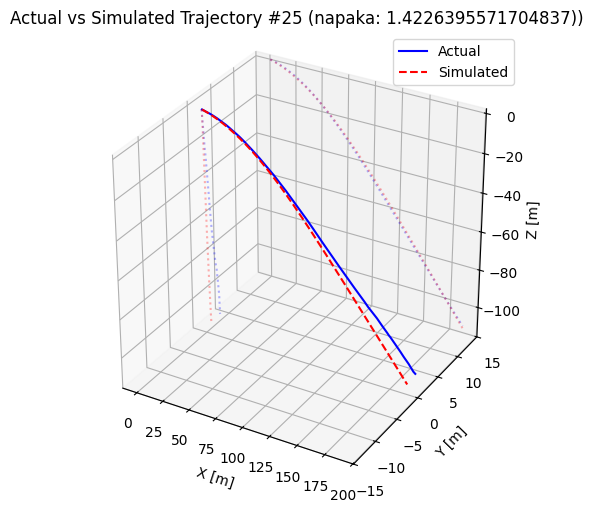

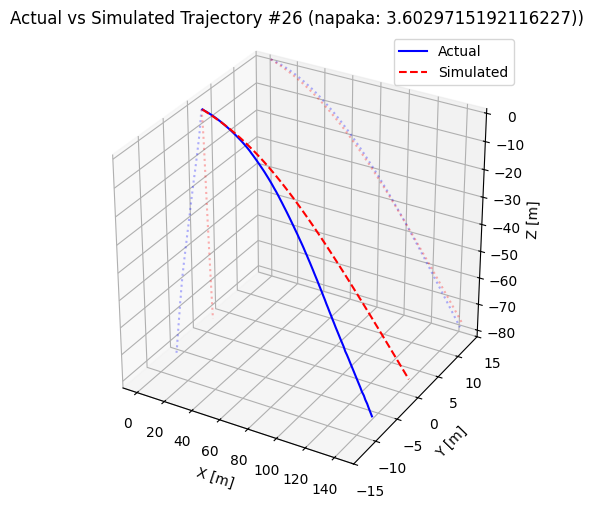

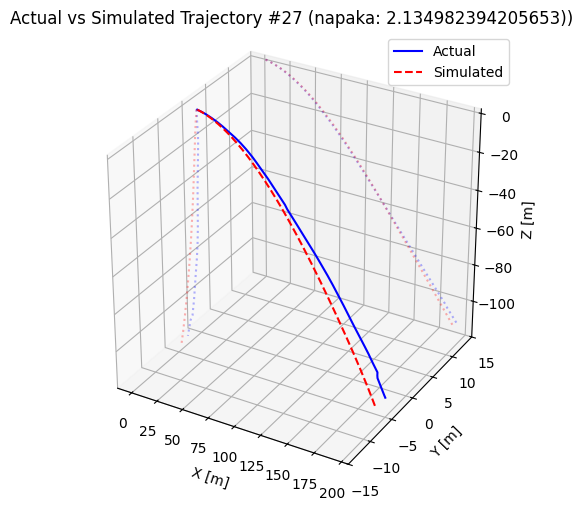

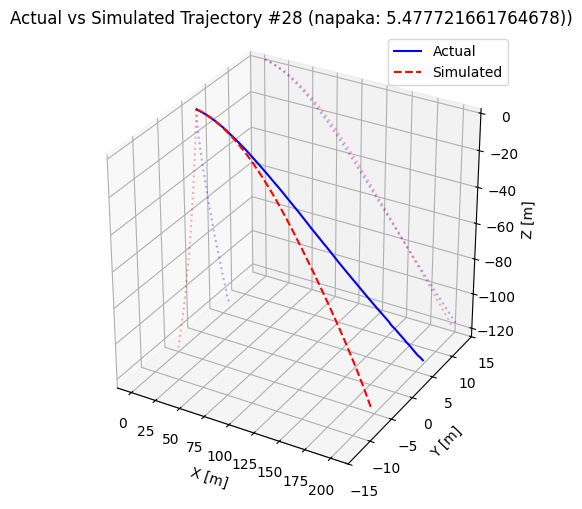

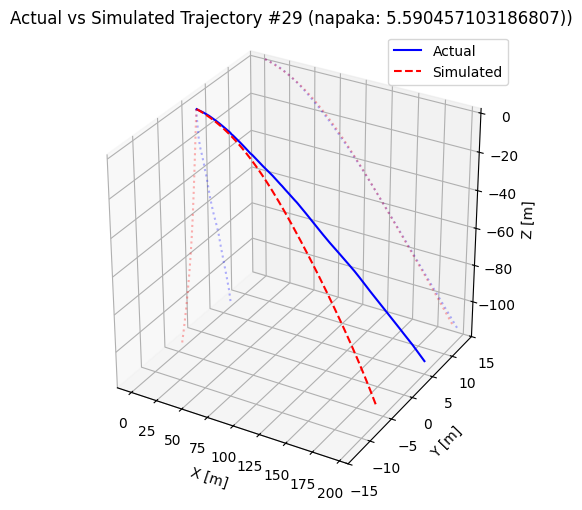

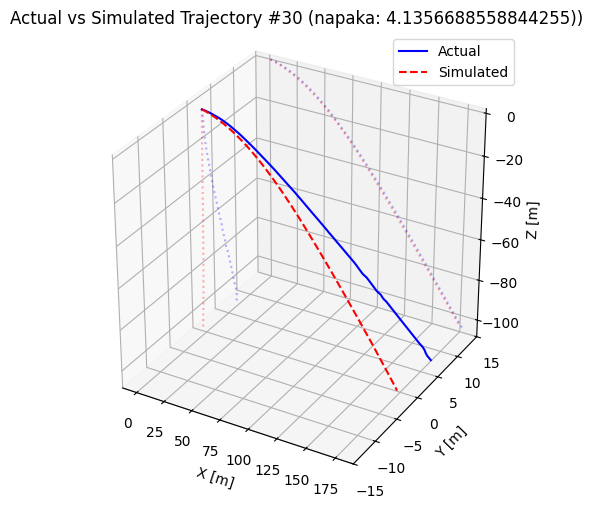

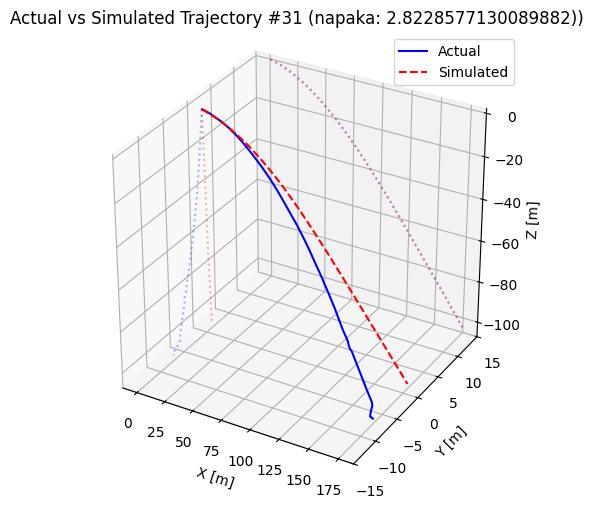

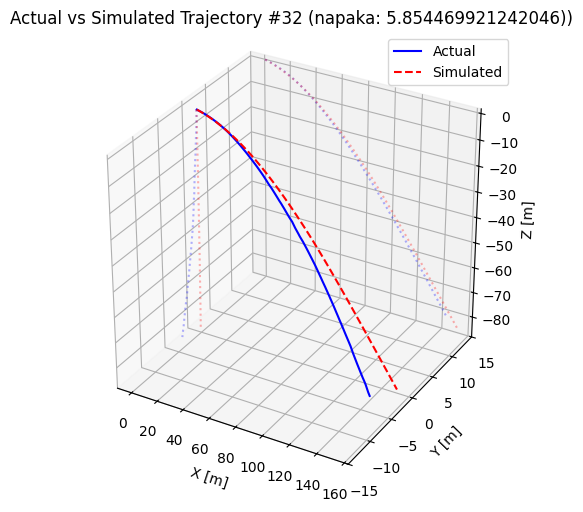

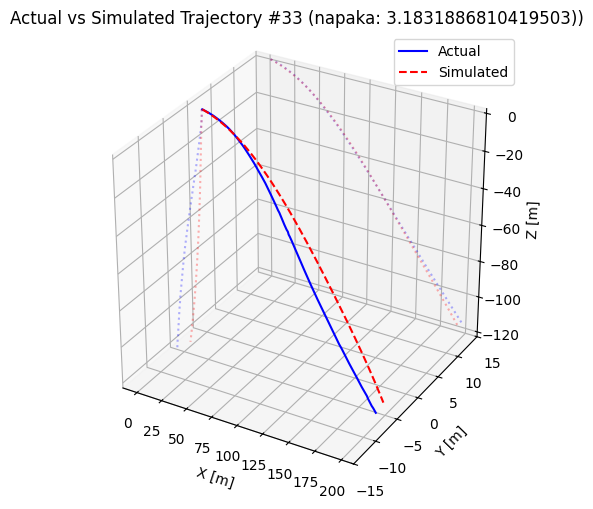

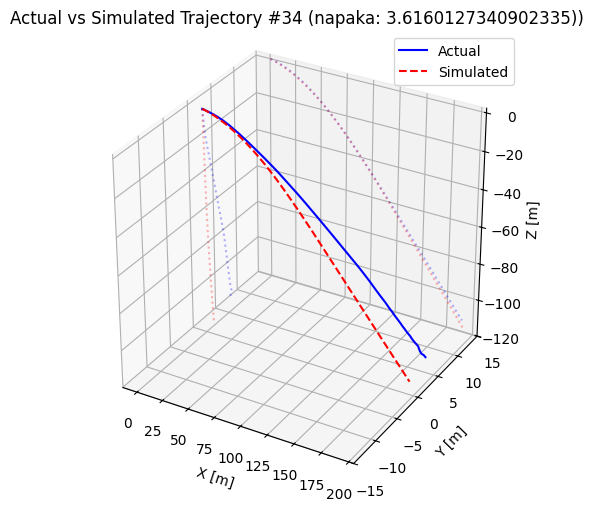

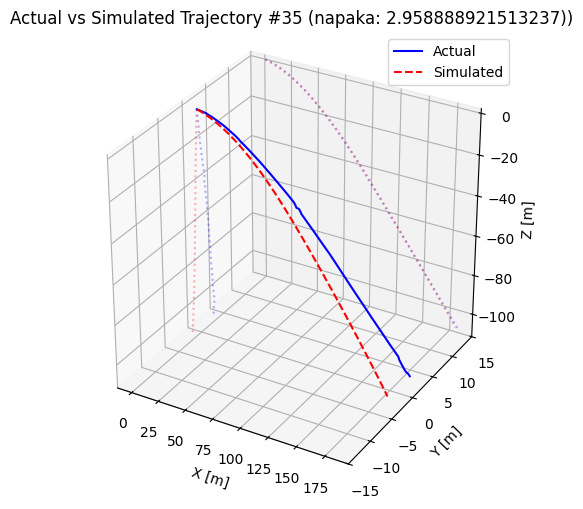

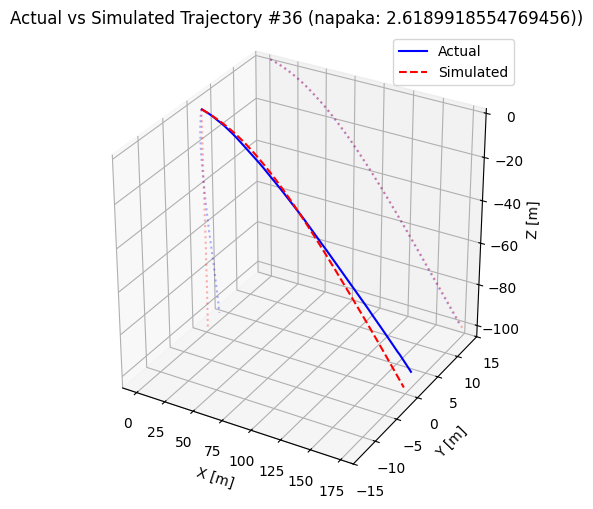

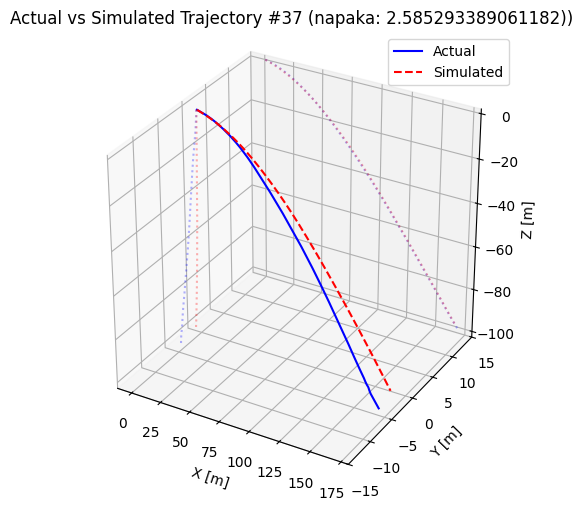

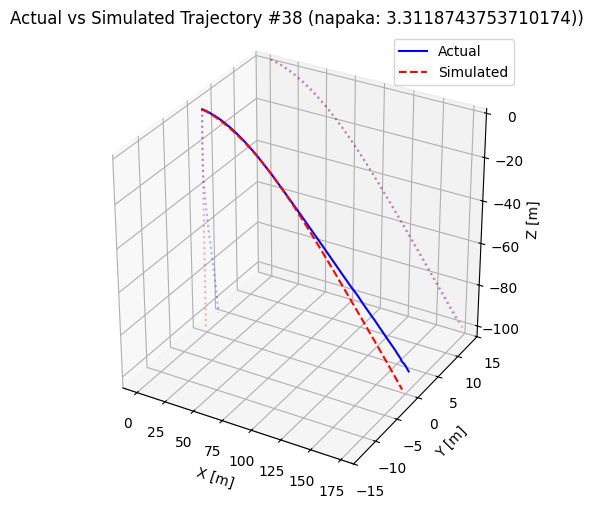

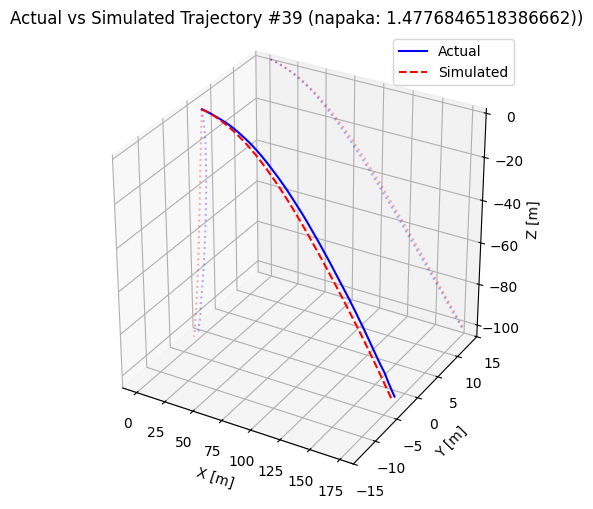

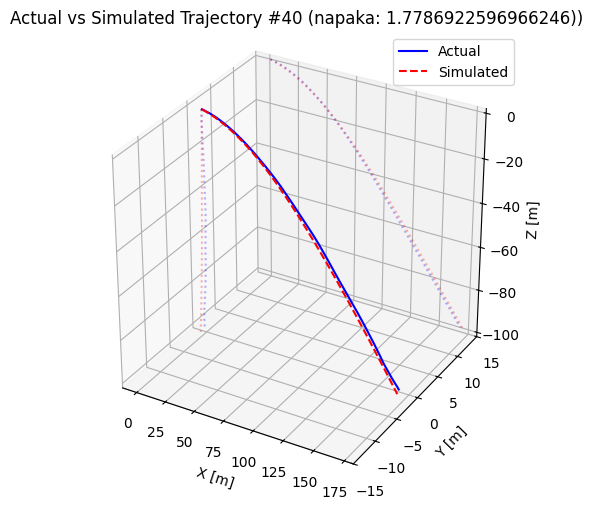

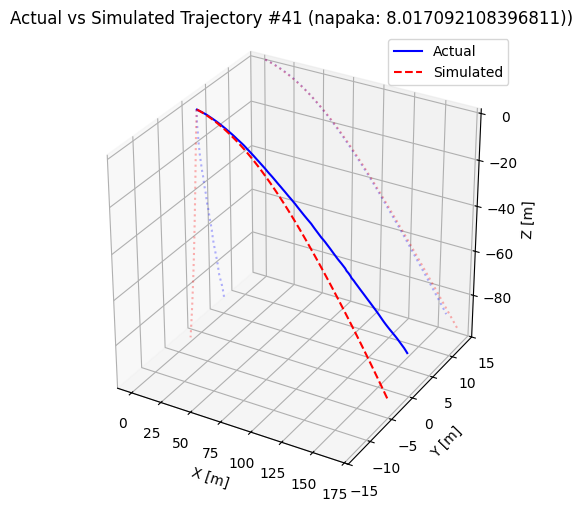

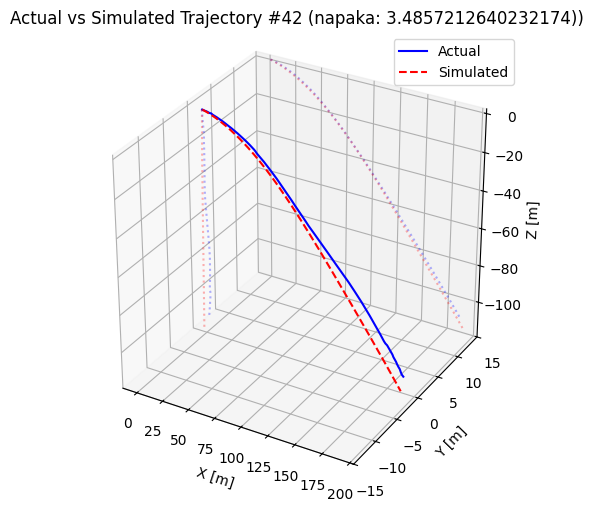

3.9892104911791257


In [47]:

#save_dir = "plots/normalized_SSM"
#os.makedirs(save_dir, exist_ok=True)

napake = []

for idx in range(len(X_test)):

    jump_idx = idx

    x0 = X_test[jump_idx][0]    #0...std in 1...norm 
    U_seq = U_test[jump_idx]      # controls for that flight
    #X_sim = simulate(A_stable, B_new, b_new, x0, U_seq)
    X_sim = simulate_trajectory(x0, U_seq, A, B)


    actual = X_test[jump_idx][:, :3]
    sim = X_sim[:, :3]


    Xa = actual[:,0]
    Ya = actual[:,1]
    Za = actual[:,2]

    Xs = sim[:,0]
    Ys = sim[:,1]
    Zs = sim[:,2]

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot3D(Xa, Ya, Za, label="Actual", color="blue")
    ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")


    # Ground projections
    ax.plot(Xa, 15, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')


    ax.plot(0, Ya, Za, color="blue", alpha=0.3, linestyle=':')
    ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')


    napaka = penalized_bidirectional_distance(actual, sim, 0.5)
    napake.append(napaka)

    ax.set_title(f"Actual vs Simulated Trajectory #{jump_idx + 1} (napaka: {napaka}))")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.legend()
    ax.set_box_aspect([1,1,1])
    ax.set_ylim(-15, 15)

    plt.legend()
    plt.tight_layout()

    #name = f"flight_simulation{jump_idx + 1}.png"
    #plt.savefig(os.path.join(save_dir, name), dpi=300)

    plt.show()
    
print(np.average(napake))

## leave-one-out cross-validation

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

def fit_ssm_cv(X_list, U_list, Y_list, n_splits=5, alpha=1e-3):
    """
    Fit an SSM model using K-fold cross-validation across jumps.

    Args:
        X_list, U_list, Y_list: lists of arrays (one per jump)
        n_splits (int): number of folds (or = len(X_list) for LOOCV)
        alpha (float): ridge regularization parameter

    Returns:
        avg_train_err, avg_test_err, models (list of (A,B,C,D) per fold)
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_errors, test_errors = [], []
    models = []

    for train_idx, test_idx in kf.split(X_list):
        # --- build training data ---
        X_t = np.vstack([seq[:-1] for i, seq in enumerate(X_list) if i in train_idx])
        X_next = np.vstack([seq[1:] for i, seq in enumerate(X_list) if i in train_idx])
        U_t = np.vstack([u[:-1] for i, u in enumerate(U_list) if i in train_idx])
        Y_t = np.vstack([y[:-1] for i, y in enumerate(Y_list) if i in train_idx])

        # Regression [X_next] ~ [X_t | U_t]
        Phi = np.hstack([X_t, U_t])
        ridge = Ridge(alpha=alpha, fit_intercept=False)     #ridge is just MNK z regularizacijo
                #
        ridge.fit(Phi, X_next)
        Theta = ridge.coef_.T

        state_dim = X_t.shape[1]
        control_dim = U_t.shape[1]
        A = Theta[:state_dim, :].T
        B = Theta[state_dim:, :].T

        # Regression [Y_t] ~ [X_t | U_t]
        Phi_y = np.hstack([X_t, U_t])
        ridge_y = Ridge(alpha=alpha, fit_intercept=False)
        ridge_y.fit(Phi_y, Y_t)
        Theta_y = ridge_y.coef_.T

        obs_dim = Y_t.shape[1]
        C = Theta_y[:state_dim, :].T
        D = Theta_y[state_dim:, :].T

        models.append((A, B, C, D))

        # --- compute training error ---
        train_sim = X_t @ A.T + U_t @ B.T
        train_err = np.mean(np.linalg.norm(train_sim[:, :3] - X_next[:, :3], axis=1))
        #train_err = penalized_bidirectional_distance(train_sim[::10], X_next[::10])
        train_errors.append(train_err)

        # --- compute test error ---
        test_errs = []
        for j in test_idx:
            x0 = X_list[j][0]       #initial state...adjust it
            U_seq = U_list[j]
            X_seq = X_list[j]

            # simulate with learned model
            X_sim = [x0]
            for t in range(len(U_seq)-1):
                x_next = A @ X_sim[-1] + B @ U_seq[t]
                X_sim.append(x_next)
            X_sim = np.array(X_sim)

            # compare to ground truth
            test_err = np.mean(np.linalg.norm(X_seq[:, :3] - X_sim[:, :3], axis=1))
            #test_err = penalized_bidirectional_distance(X_seq[::10], X_sim[::10])
            test_errs.append(test_err)

            plot(X_seq, X_sim, j, "2-SSM")
        test_errors.append(np.mean(test_errs))

        print(train_err, np.mean(test_errs))
    

    return np.mean(train_errors), np.mean(test_errors), models


In [46]:
avg_train_err, avg_test_err, models = fit_ssm_cv(X_list, U_list, Y_list, n_splits=len(X_list), alpha=10)

print("average train error:", avg_train_err)
print("average test_error:", avg_test_err)

0.10103137702375659 1.5222057043312456
0.1010661620123429 1.31682727655741
0.10100469048716922 3.5695344575569115
0.10107623056046192 1.1449404302813357
0.10103494037285214 1.7787714226376534
0.10092171500466839 6.142982229223646
0.10050687502040856 2.8945281066034823
0.10101176735873968 4.159699991416931
0.10095971793888542 3.2350119471870493
0.1010641211054033 2.4328246288244935
0.10107170811720169 3.178560144241317
0.10074522688888753 2.0954258855365953
0.1010043834755296 4.075679016735823
0.1009943921265091 6.794353275035735
0.10090177789323483 3.722840767626392
0.10055606017866028 3.468545945579552
0.10099527145196986 1.8754282626028491
0.10060366409707877 5.933172749250142
0.10102457075022929 5.498746920157579
0.10091118155931467 2.0684254087726166
0.10102434046500017 3.39974054042768
0.10105473695256562 2.9328483692979943
0.10103888209073085 7.987941954760121
0.10092966868124995 5.3966745141159524
0.10094124891390424 2.3695084751945483
0.10083809294722239 3.770372174469636
0.100

## izolacija test

In [135]:
x0

array([ 4.30621118e-01,  0.00000000e+00, -8.14285714e-02,  2.67405970e+02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  9.93788820e-01,
       -1.29409938e+00,  1.73944099e+00,  4.69875776e-01, -5.25776398e-01,
       -1.11034161e+01, -1.08770186e+01])

In [148]:
y0 = np.zeros(14)
y0[0:3] = np.ones(3)
y0

array([1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

def plot_simulated(X_sim, j, name):
    """
    Plot actual vs simulated trajectory in 3D with projections.
    Args:
        X_seq (ndarray): ground truth state sequence (T, state_dim)
        X_sim (ndarray): simulated state sequence (T, state_dim)
        j (int): index of jump
        name (str): identifier for saving plots """

    #save_dir = f"plots/{name}"
    #os.makedirs(save_dir, exist_ok=True)

    
    sim = X_sim[:, :3]          # same iz simulacije

    Xs, Ys, Zs = sim[:,0], sim[:,1], sim[:,2]

    length = (Xs[-1]**2 + Ys[-1]**2 + Zs[-1]**2)**(1/2)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")


    # Ground projections
    ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')
    ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')


    ax.set_title(f"Simulated Trajectory\n Jump length: {length:.3f})")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.legend()
    ax.set_box_aspect([1,1,1])
    ax.set_ylim(-15, 15)

    plt.legend()
    #plt.tight_layout()

    #filename = f"2SSM flight_simulation{j + 1}.png"
    #plt.savefig(os.path.join(save_dir, filename), dpi=300)
    #plt.close(fig)
    plt.show()


In [57]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

def fit_ssm_test(X_list, U_list, Y_list,j=-29, wind_value=2, n_splits=5, alpha=1e-3):
    """
    Fit an SSM model on all except one.

    Args:
        X_list, U_list, Y_list: lists of arrays (one per jump)
        n_splits (int): number of folds (or = len(X_list) for LOOCV)
        alpha (float): ridge regularization parameter

    Returns:
        the plot of the one element separated and adjusted
    """
    #kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_errors, test_errors = [], []
    models = []

    train_idx = [i for i in range(len(X_list) - 1)]

    # --- build training data ---
    X_t = np.vstack([seq[:-1] for i, seq in enumerate(X_list) if i in train_idx])
    X_next = np.vstack([seq[1:] for i, seq in enumerate(X_list) if i in train_idx])
    U_t = np.vstack([u[:-1] for i, u in enumerate(U_list) if i in train_idx])
    Y_t = np.vstack([y[:-1] for i, y in enumerate(Y_list) if i in train_idx])

    # Regression [X_next] ~ [X_t | U_t]
    Phi = np.hstack([X_t, U_t])
    ridge = Ridge(alpha=alpha, fit_intercept=False)     #ridge is just MNK z regularizacijo
            #
    ridge.fit(Phi, X_next)
    Theta = ridge.coef_.T

    state_dim = X_t.shape[1]
    control_dim = U_t.shape[1]
    A = Theta[:state_dim, :].T
    B = Theta[state_dim:, :].T

        # Regression [Y_t] ~ [X_t | U_t]
    Phi_y = np.hstack([X_t, U_t])
    ridge_y = Ridge(alpha=alpha, fit_intercept=False)
    ridge_y.fit(Phi_y, Y_t)
    Theta_y = ridge_y.coef_.T

    obs_dim = Y_t.shape[1]
    C = Theta_y[:state_dim, :].T
    D = Theta_y[state_dim:, :].T

    models.append((A, B, C, D))

        # --- compute training error ---
    train_sim = X_t @ A.T + U_t @ B.T
    train_err = np.mean(np.linalg.norm(train_sim[:, :3] - X_next[:, :3], axis=1))
    #train_err = penalized_bidirectional_distance(train_sim[::10], X_next[::10])
    train_errors.append(train_err)

        # --- compute test error ---
    test_errs = []

    
    #j = -29

    x0 = X_list[j][0]       #initial state...you can adjust it
    U_seq = np.copy(U_list[j])
    X_seq = X_list[j]

    file_length = len(U_seq)
    
    for idx, values in enumerate(U_seq):
        for i in [3, 4, 5]:
            U_seq[idx][i] = wind_value
    print(U_seq[0])


    # simulate with learned model
    X_sim = [x0]

    for t in range(file_length-1):
        x_next = A @ X_sim[-1] + B @ U_seq[t]
        X_sim.append(x_next)
    X_sim = np.array(X_sim)

    plot_simulated(X_sim, j, "2-SSM")


In [162]:
file_length = len(U_seq)
file_length

129

[ 0.8         0.81887255  0.5        -3.         -3.         -3.
  0.30313725  0.60132353  0.26147059  0.19591503  0.08627451  0.0764902 ]


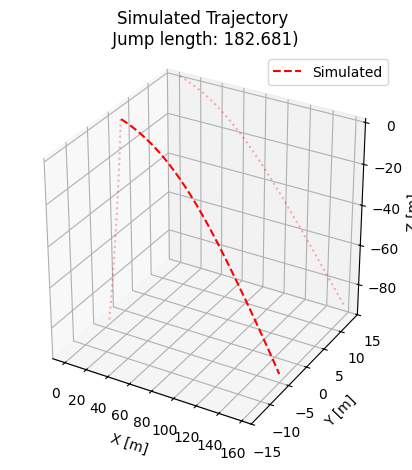

In [60]:
fit_ssm_test(X_list, U_list, Y_list, -29, -3, n_splits=len(X_list), alpha=10)


In [31]:
a = [1]
b = [2]
c = [np.array(a), np.array(b)]
c = np.array(c)
c[0][0] = 4
c[0,0] = 3
c

array([[3],
       [2]])

## z dodanimi kvadrati za veter

In [37]:
wind_features = ["Speed", "Tangent", "Cross", "Turbulence", "Speed_quad", "Tangent_quad", "Cross_quad", "Turbulence_quad"]

In [38]:


def preprocess_flight_normalized(df, step=0.05):
    """
    Preprocess a normalized flight dataframe (already interpolated) to generate states (X), observations (Y), and controls (U).
    
    Args:
        df (pd.DataFrame): Normalized flight dataframe (fixed time step).
        step (float): Time step between rows (used for derivatives).
        
    Returns:
        states (np.ndarray): State matrix [time_steps, state_dim].
        observations (np.ndarray): Observation matrix [time_steps, obs_dim].
        controls (np.ndarray): Control matrix [time_steps, control_dim].
    """

    df.columns = df.columns.str.strip()   #izloči imena stolpcev
    df = df.iloc[1:]
    
    df = df.ffill().bfill()   #back fill za manjkajoče vrednosti
    
    x = df["X [m]"].to_numpy()   #save values
    y = df["Y [m]"].to_numpy()
    z = df["Z [m]"].to_numpy()
    
    dt = step
    #vx = np.gradient(x, dt)   #gradient za hitrost
    vx = df.get("Speed hor. [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)
    vy = np.gradient(y, dt)
    #vz = np.gradient(z, dt)
    vz = df.get("Speed ver. [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)

    speed = df.get("speed resulting [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)

    opening = df.get("Opening Angle [°]", pd.Series([0]*len(x))).to_numpy()
    roll_L = df.get("Roll Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    roll_R = df.get("Roll Angle Right [°]", pd.Series([0]*len(x))).to_numpy()
    yaw_L = df.get("Yaw Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    yaw_R = df.get("Yaw Angle Right [°]", pd.Series([0]*len(x))).to_numpy()
    stall_L = df.get("Stalling Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    stall_R = df.get("Stalling Angle Right [°]", pd.Series([0]*len(x))).to_numpy()

    states = np.stack([x, y, z, vx, vy, vz, speed, opening, roll_L, roll_R, yaw_L, yaw_R, stall_L, stall_R], axis=1)   #zgradimo state vector X

    height = df.get("Height above ground [m]", pd.Series([0]*len(x))).to_numpy()

    observations = np.stack([x, y, z, height], axis=1)   #zgradimo observation vector Y

    zone_feature_avgs = []
    #values = []
    #cols = []

    #for feature in wind_features:
    #    for sensor_numb in range(12):
    #        sensor = f"W{sensor_numb + 1}"
    #        cols.append(f"{sensor}_{feature}")
    #        #print(cols)
    #for col in cols:
    #    val = df.get(col, pd.Series([0]*len(x))).to_numpy() 
    #    values.append(val)
    #
    #controls = np.stack(values, axis=1)  # shape: (time_steps, 12)

    for feature in wind_features:
        for zone, sensors in zones.items():
            cols = [f"{sensor}_{feature}" for sensor in sensors if f"{sensor}_{feature}" in df.columns]
            avg_feature = df[cols].mean(axis=1).to_numpy()
            zone_feature_avgs.append(avg_feature)
    
    controls = np.stack(zone_feature_avgs, axis=1)  # shape: (time_steps, 12)
    
    return states, observations, controls


In [39]:
import os
import pandas as pd
import numpy as np

normalized_folder = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\simulation\2024_03_Planica_12_winds\cleaned\cleaned_quad\normalized_quad'
combined_output = os.path.join(normalized_folder, "combined_dataset.npz")
file_names = []

X_list, Y_list, U_list = [], [], []

for filename in os.listdir(normalized_folder):
    if filename.endswith('.csv'):
        file_path = os.path.join(normalized_folder, filename)
        df = pd.read_csv(file_path)

        X_state, Y_obs, U_ctrl = preprocess_flight_normalized(df)

        X_list.append(X_state)
        Y_list.append(Y_obs)
        U_list.append(U_ctrl)
        file_names.append(filename)

        #if np.any(np.isnan(X_state)):
        #    print(f"NaN values in {filename}")

        print(f"Processed {filename} -> X:{X_state.shape}, Y:{Y_obs.shape}, U:{U_ctrl.shape}")

# Save combined dataset
#np.savez(combined_output, X=np.array(X_list, dtype=object), Y=np.array(Y_list, dtype=object), U=np.array(U_list, dtype=object))
print(f"\nCombined dataset saved to {combined_output}")


Processed 999_999_Jumper_Anon_ANO_1_20240409-102625_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(133, 14), Y:(133, 4), U:(133, 24)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102742_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(129, 14), Y:(129, 4), U:(129, 24)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102831_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(142, 14), Y:(142, 4), U:(142, 24)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102832_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(135, 14), Y:(135, 4), U:(135, 24)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102833_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(132, 14), Y:(132, 4), U:(132, 24)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102834_C_OfficialResults_cleaned_quad-cleaned_normalized-quad.csv -> X:(131, 14), Y:(131, 4), U:(131, 24)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102835_C_OfficialResults_cleaned_quad-cleaned_nor

In [40]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

def fit_ssm_cv_quad(X_list, U_list, Y_list, n_splits=5, alpha=1e-3):
    """
    Fit an SSM model using K-fold cross-validation across jumps.

    Args:
        X_list, U_list, Y_list: lists of arrays (one per jump)
        n_splits (int): number of folds (or = len(X_list) for LOOCV)
        alpha (float): ridge regularization parameter

    Returns:
        avg_train_err, avg_test_err, models (list of (A,B,C,D) per fold)
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_errors, test_errors = [], []
    models = []

    for train_idx, test_idx in kf.split(X_list):
        # --- build training data ---
        X_t = np.vstack([seq[:-1] for i, seq in enumerate(X_list) if i in train_idx])
        X_next = np.vstack([seq[1:] for i, seq in enumerate(X_list) if i in train_idx])
        U_t = np.vstack([u[:-1] for i, u in enumerate(U_list) if i in train_idx])
        Y_t = np.vstack([y[:-1] for i, y in enumerate(Y_list) if i in train_idx])

        # Regression [X_next] ~ [X_t | U_t]
        Phi = np.hstack([X_t, U_t])
        ridge = Ridge(alpha=alpha, fit_intercept=False)     #ridge is just MNK z regularizacijo
                #
        ridge.fit(Phi, X_next)
        Theta = ridge.coef_.T

        state_dim = X_t.shape[1]
        control_dim = U_t.shape[1]
        A = Theta[:state_dim, :].T
        B = Theta[state_dim:, :].T

        # Regression [Y_t] ~ [X_t | U_t]
        Phi_y = np.hstack([X_t, U_t])
        ridge_y = Ridge(alpha=alpha, fit_intercept=False)
        ridge_y.fit(Phi_y, Y_t)
        Theta_y = ridge_y.coef_.T

        obs_dim = Y_t.shape[1]
        C = Theta_y[:state_dim, :].T
        D = Theta_y[state_dim:, :].T

        models.append((A, B, C, D))

        # --- compute training error ---
        train_sim = X_t @ A.T + U_t @ B.T
        train_err = np.mean(np.linalg.norm(train_sim[:, :3] - X_next[:, :3], axis=1))
        #train_err = penalized_bidirectional_distance(train_sim[::10], X_next[::10])
        train_errors.append(train_err)

        # --- compute test error ---
        test_errs = []
        for j in test_idx:
            x0 = X_list[j][0]       #initial state...adjust it
            U_seq = U_list[j]
            X_seq = X_list[j]

            # simulate with learned model
            X_sim = [x0]
            for t in range(len(U_seq)-1):
                x_next = A @ X_sim[-1] + B @ U_seq[t]
                X_sim.append(x_next)
            X_sim = np.array(X_sim)

            # compare to ground truth
            test_err = np.mean(np.linalg.norm(X_seq[:, :3] - X_sim[:, :3], axis=1))
            #test_err = penalized_bidirectional_distance(X_seq[::10], X_sim[::10])
            test_errs.append(test_err)

            plot(X_seq, X_sim, j, "2-SSM-quad")
        test_errors.append(np.mean(test_errs))

        print(train_err, np.mean(test_errs))

    return np.mean(train_errors), np.mean(test_errors), models


In [41]:
avg_train_err, avg_test_err, models = fit_ssm_cv_quad(X_list, U_list, Y_list, n_splits=len(X_list), alpha=10)

print("average train error:", avg_train_err)
print("average test_error:", avg_test_err)

0.07061644620485004 1.3108978964508384
0.07055167640121089 1.0889070517695258
0.07056963842703434 2.870948762367167
0.07058678205302275 1.887672432564605
0.07059932379835983 3.520465731878954
0.070457705757163 6.722525498518483
0.07004804498465135 4.235578961629395
0.07052398118014362 4.368306878782774
0.07038773260951331 3.5483236933420708
0.07063375789413837 1.92312645955896
0.07061040724642458 7.037743945088012
0.07033095323888135 1.7576381054960573
0.07060331823420388 2.2137537625061374
0.07061002062999686 5.016570664358328
0.07046924009999204 2.707806360644357
0.07022487060375603 4.430348168213257
0.07048095356369181 2.664011621957292
0.06985319794079818 5.449344498686538
0.07035263128992987 5.66093713687498
0.07025679703925786 4.1381674638965285
0.07058229024683096 2.6967425734147112
0.07054084955923362 2.220782999216509
0.07059755180816044 3.5052617217465287
0.07054962678062958 2.8085712084729257
0.07062876986293981 2.7919851103704083
0.07043045969839606 3.178686460374076
0.0703